In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from scipy.optimize import minimize

In [ ]:
resetar_banco = False
rodar_nm = False

In [ ]:
import os
import glob

# Sua variável de controle

# Caminho da pasta que será limpa
caminho_pasta = r'.\tests_nm\results'

if resetar_banco:
    # Cria uma lista com todos os itens (*) dentro da pasta
    arquivos = glob.glob(os.path.join(caminho_pasta, '*'))
    
    if not arquivos:
        print("A pasta já está vazia.")
    else:
        for arquivo in arquivos:
            try:
                # Garante que vai apagar apenas arquivos, ignorando subpastas caso existam
                if os.path.isfile(arquivo):
                    os.remove(arquivo)
                    print(f"Arquivo apagado: {arquivo}")
            except Exception as e:
                print(f"Erro ao tentar apagar {arquivo}: {e}")
                
        print(f"Limpeza da pasta {caminho_pasta} concluída com sucesso!")



Arquivo apagado: .\tests_nm\results\nm_occ0.2.csv
Arquivo apagado: .\tests_nm\results\nm_occ0.5.csv
Arquivo apagado: .\tests_nm\results\nm_occ0.7.csv
Arquivo apagado: .\tests_nm\results\nm_occ0.9.csv
Limpeza da pasta .\tests_nm\results concluída com sucesso!


In [3]:
data = [pd.read_csv(r'database\data_occ0_2.csv'),
        pd.read_csv(r'database\data_occ0_5.csv'),
        pd.read_csv(r'database\data_occ0_7.csv'),
        pd.read_csv(r'database\data_occ0_9.csv'),]

phases = [pd.read_csv(r'database\original-database\occupancy_0.2.CSV', index_col = False)['phases'][3:69997],
          pd.read_csv(r'database\original-database\occupancy_0.5.CSV', index_col = False)['phases'][3:69997],
          pd.read_csv(r'database\original-database\occupancy_0.7.CSV', index_col = False)['phases'][3:69997],
          pd.read_csv(r'database\original-database\occupancy_0.9.CSV', index_col = False)['phases'][3:69997]]

for i in range(4):
    data[i]['phases'] = phases[i].values

columns = data[0].columns # salva os nomes das colunas
occ_name = ['occ0.2', 'occ0.5', 'occ0.7', 'occ0.9']
tol = [1e-4, 1e-3, 1e-2, 1e-1, 1]

In [4]:

#Função objetivo


#Método de Nelder-Mead
def nelderMead(df, tol):

    def objectiveFunction(A):
        signalPattern = np.array([
            A[0]*1.0    + A[1]*0.4524   + A[2]*0.0172   + 0             + 0             + 0             + 0,
            A[0]*0.5633 + A[1]*1        + A[2]*0.4524   + A[3]*0.0172   + 0             + 0             + 0,
            A[0]*0.1493 + A[1]*0.5633   + A[2]*1        + A[3]*0.4524   + A[4]*0.0172   + 0             + 0,
            A[0]*0.0424 + A[1]*0.1493   + A[2]*0.5633   + A[3]*1        + A[4]*0.4524   + A[5]*0.0172   + 0,
            0           + A[1]*0.0424   + A[2]*0.1493   + A[3]*0.5633   + A[4]*1        + A[5]*0.4524   + A[6]*0.0172,
            0           + 0             + A[2]*0.0424   + A[3]*0.1493   + A[4]*0.5633   + A[5]*1        + A[6]*0.4524,
            0           + 0             + 0             + A[3]*0.0424   + A[4]*0.1493   + A[5]*0.5633   + A[6]*1
            ])
        aux_sum = samples - signalPattern # "samples" are declared in each iteration of the for loop
        return (sum(aux_sum**2) / len(samples))**0.5
    
    res_list = []
    sample4 = []
    iter_list = []
    fun_list = []
    for samples in df:
        res = minimize(objectiveFunction, samples, method='Nelder-Mead', options={'xatol': tol})
        
        fun = res.fun
        iter = res.nit

        fun_list.append(fun)
        iter_list.append(iter)
        res_list.append(res.x)

        sample4.append(res.x[3])
        #print(f'Sample {len(sample4)} done')


    return res_list, sample4, iter_list, fun_list

In [5]:
def save_nm(sample, sample4, iter_list, tol, occ, phase, fun_list):
    path = f'.\\tests_nm\\results\\nm_{occ}.csv'

    if os.path.exists(path):
        df = pd.read_csv(path)
        new_df = pd.DataFrame({'sample(0)': [s[0] for s in sample], 
                               'sample(1)': [s[1] for s in sample], 
                               'sample(2)': [s[2] for s in sample], 
                               'sample(3)': [s[3] for s in sample], 
                               'sample(4)': [s[4] for s in sample], 
                               'sample(5)': [s[5] for s in sample], 
                               'sample(6)': [s[6] for s in sample], 
                               'AmplitudeSample(4)': sample4, 
                               'PhaseSample(4)': phase, 
                               'tolerance': tol,
                               'function_values': fun_list,
                               'iterations': iter_list,})
        df = pd.concat([df, new_df], ignore_index=True)
    else:
        df = pd.DataFrame({'sample(0)': [s[0] for s in sample], 
                        'sample(1)': [s[1] for s in sample], 
                        'sample(2)': [s[2] for s in sample], 
                        'sample(3)': [s[3] for s in sample], 
                        'sample(4)': [s[4] for s in sample], 
                        'sample(5)': [s[5] for s in sample], 
                        'sample(6)': [s[6] for s in sample], 
                        'AmplitudeSample(4)': sample4, 
                        'PhaseSample(4)': phase, 
                        'tolerance': tol,
                        'function_values': fun_list,
                        'iterations': iter_list,})
    df.to_csv(f'.\\tests_nm\\results\\nm_{occ}.csv', index=False)

In [ ]:
def run_algorithm(data):

    #reset_save() #Limpa os arquivos de resultados antes de rodar o algoritmo
    #Para cada ocupação e cada tolerância, roda o método de Nelder-Mead e salva os resultados
    if rodar_nm:
        k = 0
        for i in range(4):
            for t in tol:
                samples_data = np.array(data[i][columns[0:7]])
                amplitudes_data = np.array(data[i][columns[7]])
                phases_data = np.array(data[i][columns[8]])
                
                sample, sample4, iter_list, fun_list = nelderMead(samples_data, t)
                save_nm(sample, sample4, iter_list, t, occ_name[i], phases_data, fun_list)
                k +=1
                print(f'Occupancy {occ_name[i][3:]} and tolerance {t} done, lacking {len(tol)*4 - k} combinations')

In [7]:
run_algorithm(data)

Occupancy 0.2 and tolerance 0.0001 done, lacking 19 combinations
Occupancy 0.2 and tolerance 0.001 done, lacking 18 combinations
Occupancy 0.2 and tolerance 0.01 done, lacking 17 combinations
Occupancy 0.2 and tolerance 0.1 done, lacking 16 combinations
Occupancy 0.2 and tolerance 1 done, lacking 15 combinations
Occupancy 0.5 and tolerance 0.0001 done, lacking 14 combinations
Occupancy 0.5 and tolerance 0.001 done, lacking 13 combinations
Occupancy 0.5 and tolerance 0.01 done, lacking 12 combinations
Occupancy 0.5 and tolerance 0.1 done, lacking 11 combinations
Occupancy 0.5 and tolerance 1 done, lacking 10 combinations
Occupancy 0.7 and tolerance 0.0001 done, lacking 9 combinations
Occupancy 0.7 and tolerance 0.001 done, lacking 8 combinations
Occupancy 0.7 and tolerance 0.01 done, lacking 7 combinations
Occupancy 0.7 and tolerance 0.1 done, lacking 6 combinations
Occupancy 0.7 and tolerance 1 done, lacking 5 combinations
Occupancy 0.9 and tolerance 0.0001 done, lacking 4 combinations

In [8]:
def load_results():
    resultados = [
        pd.read_csv(r'.\tests_nm\results\nm_occ0.2.csv'),
        pd.read_csv(r'.\tests_nm\results\nm_occ0.5.csv'),
        pd.read_csv(r'.\tests_nm\results\nm_occ0.7.csv'),
        pd.read_csv(r'.\tests_nm\results\nm_occ0.9.csv'),
    ]
    return resultados

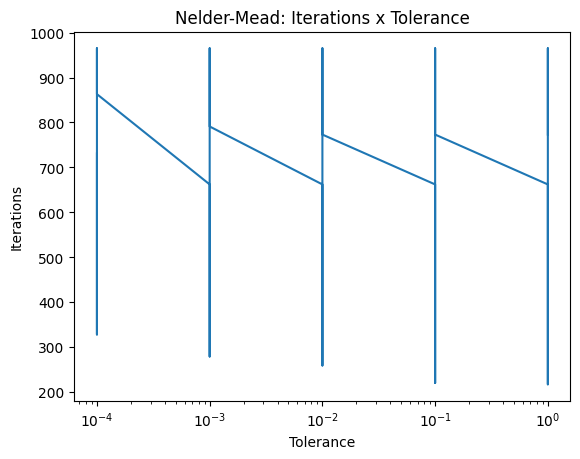

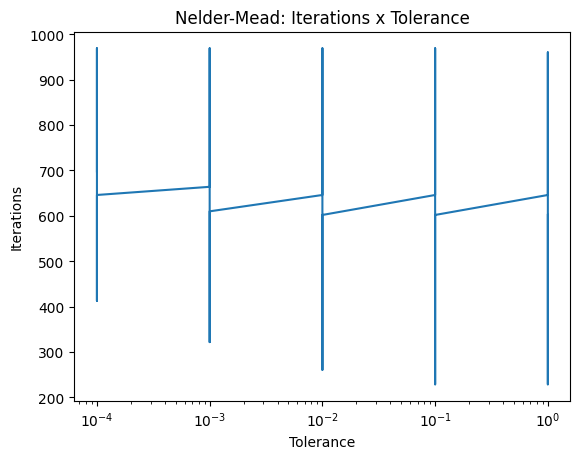

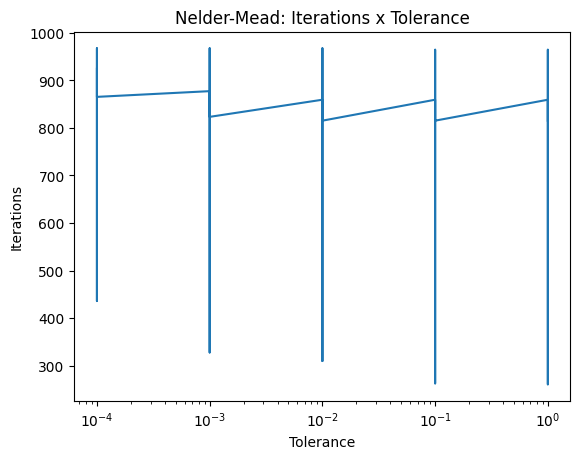

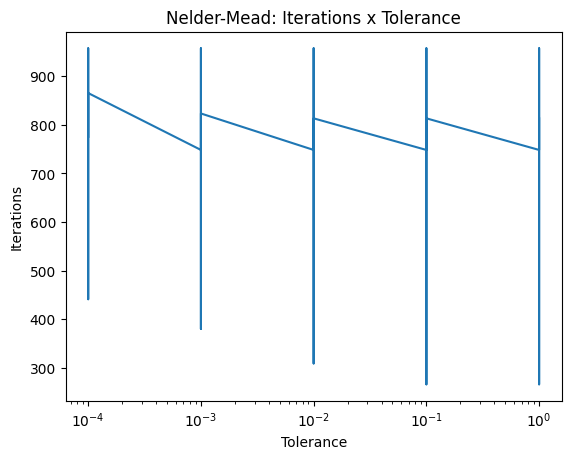

In [9]:
#Grafico de tolerance por iterations
res = load_results()

for i in range(len(res)):
    plt.plot(res[i]['tolerance'], res[i]['iterations'], label=f'Occupancy {occ_name[i][3:]}')
    plt.xlabel('Tolerance')
    plt.ylabel('Iterations')
    plt.title('Nelder-Mead: Iterations x Tolerance')
    plt.xscale('log')
    plt.show()

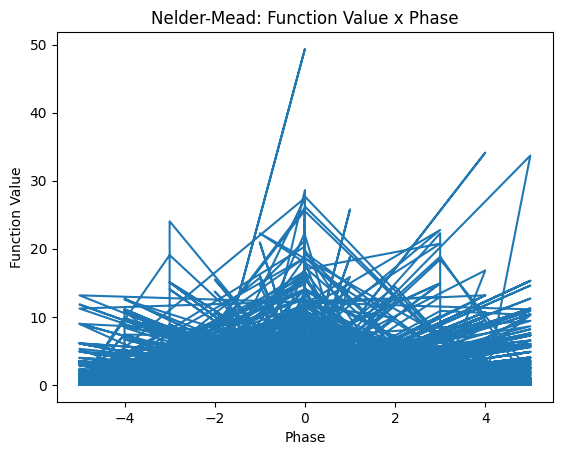

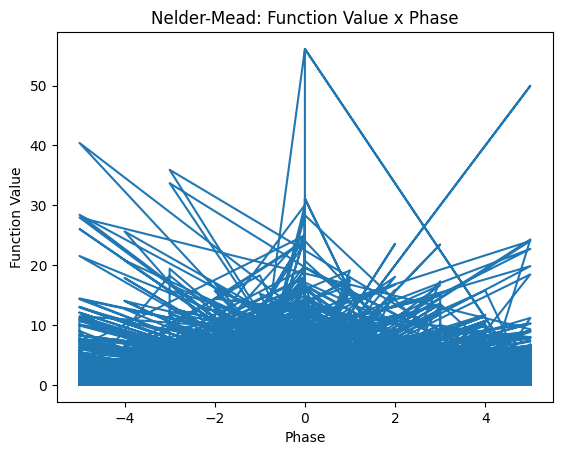

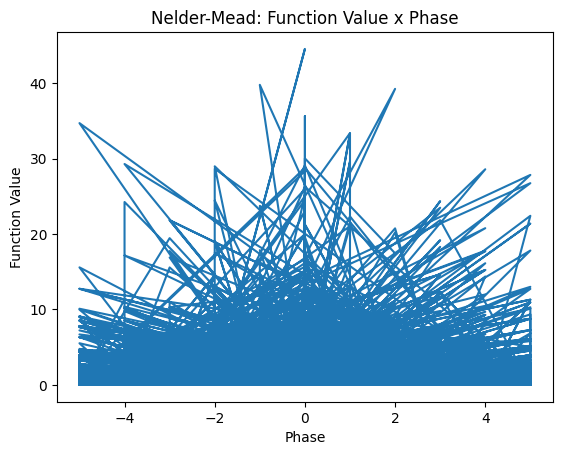

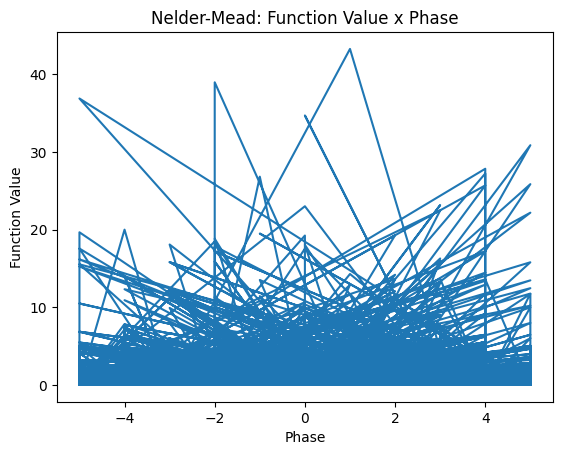

In [10]:
res = load_results()

for i in range(len(res)):
    plt.plot(res[i]['PhaseSample(4)'], res[i]['function_values'], label=f'Occupancy {occ_name[i][3:]}')
    plt.xlabel('Phase')
    plt.ylabel('Function Value')
    plt.title('Nelder-Mead: Function Value x Phase')
    plt.show()

Max function value for Occupancy 0.2: 49.35332506610525


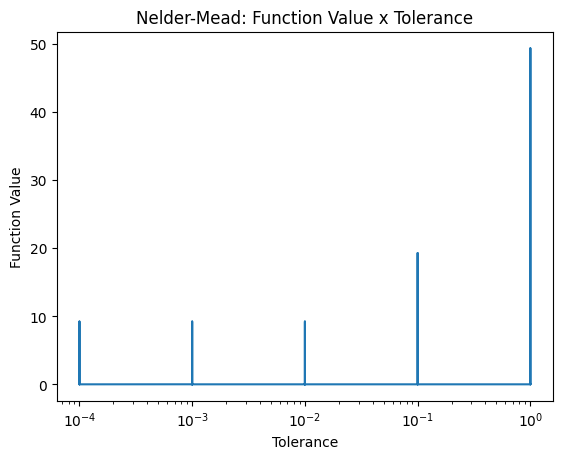

Max function value for Occupancy 0.5: 56.129223188020845


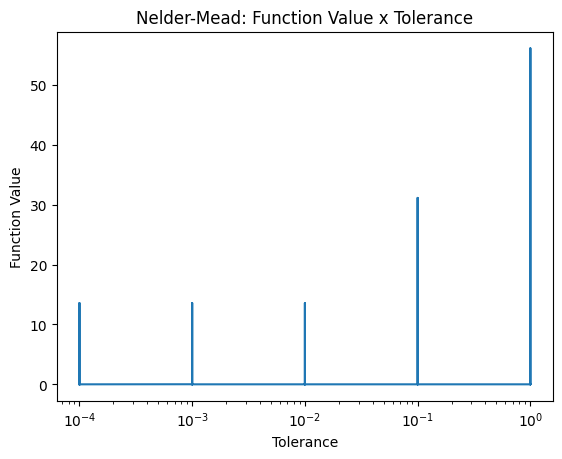

Max function value for Occupancy 0.7: 44.54418465516029


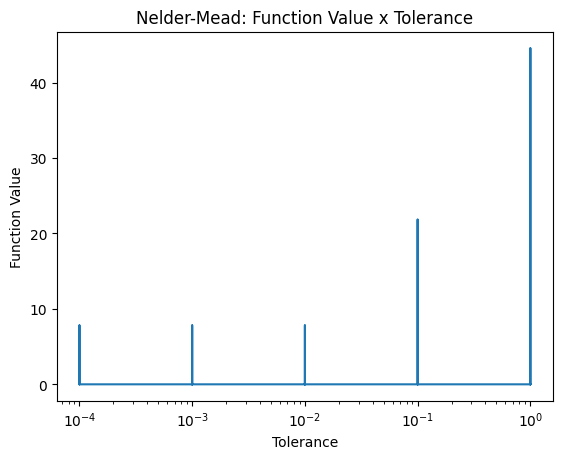

Max function value for Occupancy 0.9: 43.282853899772896


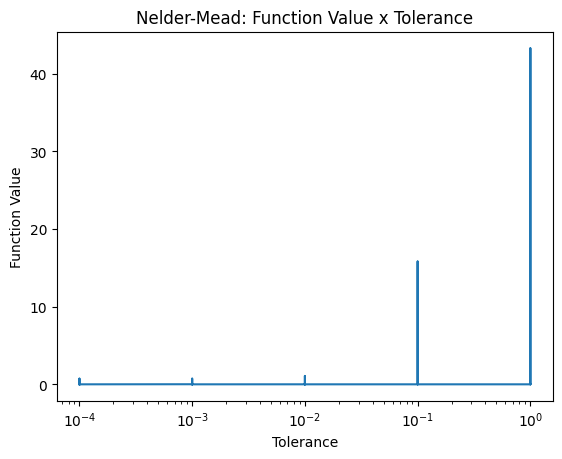

In [12]:
res = load_results()

for i in range(len(res)):
    print(f"Max function value for Occupancy {occ_name[i][3:]}: {max(res[i]['function_values'])}")
    plt.plot(res[i]['tolerance'], res[i]['function_values'], label=f'Occupancy {occ_name[i][3:]}')
    plt.xlabel('Tolerance')
    plt.ylabel('Function Value')
    plt.title('Nelder-Mead: Function Value x Tolerance')
    plt.xscale('log')
    plt.show()